# Analyzing the electrification potential of heavy-duty truck fleets using real-world GPS mobility data for charging feasibility and depot energy demand planning


Authors: Anna Paper, Georg Balke, Philip Rosborough and Markus Lienkamp

## Preparations

### Imports

In [12]:
%load_ext autoreload
%autoreload 2

import os 
import sys

import zipfile
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.table import Table
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib import colorbar
from fpdf import FPDF
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown as md
from IPython.display import display

from smvis.gridfigure import GridFigure
from smvis.utils import genLineLegendHandle, setFont, setFontSize
    
import data_visualization as dv
import data_processing as dp
from data_processing import colors_fleets, alpha_major, alpha_minor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Preprocessing

In [13]:
# Define LOCATIONS
LOCATIONS = dp.LOCATIONS

# Load data
df_trips_unfiltered, df_fleet = dp.load_data() #df_trips_unfiltered, df_fleet, zf = dp.load_data()

# # Load speed data for a specific vehicle and trip
# i_veh, i_trip = 1, 10
# df_speed = dp.load_speed_data(zf, i_veh, i_trip)

# Preprocess data
df_trips = dp.preprocess_trips_data(df_trips_unfiltered, df_fleet)
df_trips.to_csv('../input/tracks_filtered.csv')
df_stops = dp.process_stops_data(df_trips)
# df_speed = dp.convert_speed_to_kmh(df_speed)
df_occupation = dp.calculate_occupation(df_trips)

df_rt_joined_plot = dp.calculate_rest_times_and_driving(df_stops, df_trips)

# Resample occupation data
# shows time spent (in min?) not occurences
truck_day_occ = dp.resample_occupation_data(df_stops, df_trips)

h:\03 Code\sm-truck-fleet-electrification-paper\src\data_processing.py:62: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_trips['stop_time'] = pd.to_datetime(df_trips['stop_time'], format='mixed')
h:\03 Code\sm-truck-fleet-electrification-paper\src\data_processing.py:63: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_trips['start_time'] = pd.to_datetime(df_trips['start_time'], format='mixed')
h:\03 Code\sm-truck-fleet-electrification-paper\

## Analysis

### Tour statistics


In [14]:
df_tracks_filtered = pd.read_csv('../input/tracks_filtered.csv')
df_tours = dp.aggregate_tours(df_tracks_filtered)

# Calculate the percentage of tours with distance_km < 300, < 375, < 500, < 1000
distances = [300, 375, 500, 1000]
percentages = {dist: (df_tours[df_tours['distance_km'] < dist].shape[0] / df_tours.shape[0]) * 100 for dist in distances}

# Print the results
for dist, perc in percentages.items():
    print(f"Percentage of tours with distance_km < {dist}: {perc:.2f}%")

Percentage of tours with distance_km < 300: 87.35%
Percentage of tours with distance_km < 375: 91.07%
Percentage of tours with distance_km < 500: 94.01%
Percentage of tours with distance_km < 1000: 97.66%


In [15]:
# Calculation of general meta data
meta_data = dp.calculate_meta_data(df_trips_unfiltered, df_trips, df_fleet, fleet_id)
# Converting meta data to DataFrame
general_df, _, _ = dp.meta_data_to_df(meta_data)

# Display of DataFrame
display(general_df)

,Metric,Value
0,Recorded distance / km,2154400.806
1,Recorded time / h,44341.759
2,Trips,42705
3,Tours,13616
4,Vehicles,163
5,Median vehicle distance / km,7976.07
6,Share of trips shorter than 5h,0.997
7,Trips shorter than 1 km,108412
8,Total recordings,151598
9,Min start time,2021-09-07 09:48:57.981000+00:00


In [16]:
# Daten laden
df_trips_unfiltered, df_fleet = dp.load_data()

# Daten vorverarbeiten
df_trips = dp.preprocess_trips_data(df_trips_unfiltered, df_fleet)

# Speditionen definieren
SPEDITIONEN = {
    1: 'Metzger',
    2: 'Wenner',
    3: 'Mäker',
    4: 'Schwarz',
    5: 'Elflein',
    6: 'Schmid'
}

# Meta-Daten für jede Spedition berechnen und ausgeben
for fleet_id, spedition_name in SPEDITIONEN.items():
    print(f"\nSpedition: {spedition_name}")
    meta_data = dp.calculate_meta_data(df_trips_unfiltered, df_trips, df_fleet, fleet_id)
    general_df, temporal_df, spatial_df = dp.meta_data_to_df(meta_data)
    print("General meta-data:")
    display(general_df)
    print("Temporal meta-data:")
    display(temporal_df)
    print("Spatial meta-data:")
    display(spatial_df)

h:\03 Code\sm-truck-fleet-electrification-paper\src\data_processing.py:62: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_trips['stop_time'] = pd.to_datetime(df_trips['stop_time'], format='mixed')



Spedition: Metzger
General meta-data:


h:\03 Code\sm-truck-fleet-electrification-paper\src\data_processing.py:63: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_trips['start_time'] = pd.to_datetime(df_trips['start_time'], format='mixed')


,Metric,Value
0,Recorded distance / km,2154400.806
1,Recorded time / h,44341.759
2,Trips,42705
3,Tours,13616
4,Vehicles,163
5,Median vehicle distance / km,7976.07
6,Share of trips shorter than 5h,0.997
7,Trips shorter than 1 km,108412
8,Total recordings,151598
9,Min start time,2021-09-07 09:48:57.981000+00:00


Temporal meta-data:


...

,Metric,Value
0,Recorded distance / km,2154400.806
1,Recorded time / h,44341.759
2,Trips,42705
3,Tours,13616
4,Vehicles,163
5,Median vehicle distance / km,7976.07
6,Share of trips shorter than 5h,0.997
7,Trips shorter than 1 km,108412
8,Total recordings,151598
9,Min start time,2021-09-07 09:48:57.981000+00:00


Temporal meta-data:


,Metric,Value
0,Average Trips per Day per Truck,284.7
1,Average Trip Duration / h,1.038
2,Average Trip Distance / km,50.448
3,Average Trips per Tour,3.146
4,Average Daily Distance per Truck / km,214.583
5,Average Daily Start Time,06:26:50
6,Average Daily End Time,14:00:52
7,Average Speed per Trip/ km/h,37.745


Spatial meta-data:


,Metric,Value
0,Maximum Latitude,0
1,Minimum Latitude,0
2,Maximum Longitude,0
3,Minimum Longitude,0


### Temporal Pattern

In [17]:
# Converting meta data to DataFrame
_, temporal_df, _ = dp.meta_data_to_df(meta_data)

# Display of DataFrame
display(temporal_df)

,Metric,Value
0,Average Trips per Day per Truck,284.7
1,Average Trip Duration / h,1.038
2,Average Trip Distance / km,50.448
3,Average Trips per Tour,3.146
4,Average Daily Distance per Truck / km,214.583
5,Average Daily Start Time,06:26:50
6,Average Daily End Time,14:00:52
7,Average Speed per Trip/ km/h,37.745


#### Correlation Temporal Patterm

h:\03 Code\sm-truck-fleet-electrification-paper\src\data_visualization.py:104: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_trips, x='distance_km', hue='vehicle_id', ax=axes[0, 0], palette=palette, common_norm=False, fill=True)
h:\03 Code\sm-truck-fleet-electrification-paper\src\data_visualization.py:115: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_trips, x='duration_h', hue='vehicle_id', ax=axes[0, 1], palette=palette, common_norm=False, fill=True)
h:\03 Code\sm-truck-fleet-electrification-paper\src\data_visualization.py:126: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_trips, x='max_speed_kmh', hue='vehicle_id', ax=axes[1, 0], palette=palette, common_norm=False, fill=True)
h:\03 Code\sm-truck-fleet-electrific

PermissionError: [Errno 13] Permission denied: '../output/figures/temporal_pattern/kde_plots.pdf'

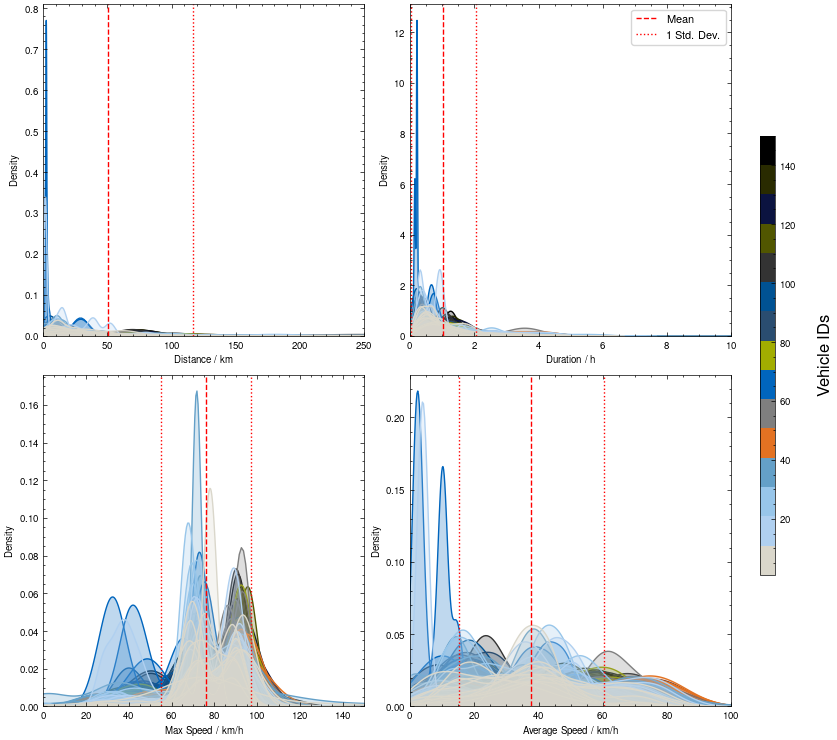

In [18]:
dv.plot_kde_plots(df_trips)

# TODO move legend further to the right (dircetly above the color scale and outside of the plot)

### Boxplot: Weekly Distance per Truck

Current font family: ['sans-serif']
Current font size: 7.0
Current font weight: normal
Current font style: normal


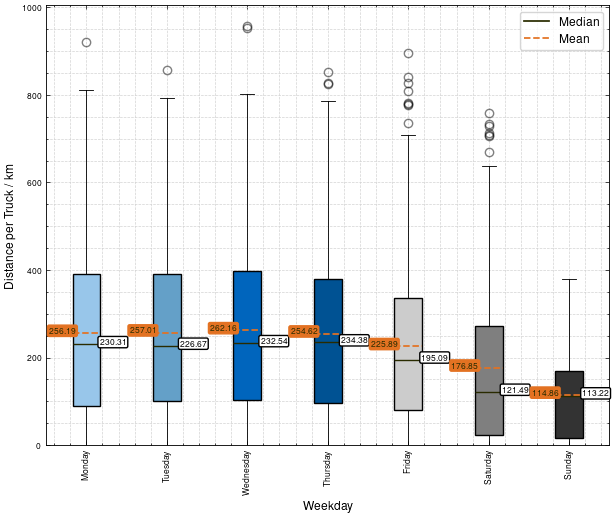

<module 'matplotlib.style' from 'c:\\Users\\ge56wuh\\AppData\\Local\\anaconda3\\Lib\\site-packages\\matplotlib\\style\\__init__.py'>
Verifying weekday aggregation:
Sample data for Monday:
      vehicle_id        date  weekday  distance_km
407            5  2021-11-22        0       12.865
7205         118  2023-10-16        0       99.504
2162          24  2021-10-25        0      380.849
7195         116  2023-10-23        0      252.413
8053         143  2023-10-16        0      316.306
Sample data for Tuesday:
      vehicle_id        date  weekday  distance_km
6382          83  2023-09-19        1      152.538
8614         159  2023-10-31        1      243.072
8505         156  2024-01-09        1      192.772
7862         137  2023-12-19        1      380.864
5975          72  2023-12-12        1        1.829
Sample data for Wednesday:
      vehicle_id        date  weekday  distance_km
8483         156  2023-11-29        2      245.624
8533         157  2023-10-11        2      163

In [19]:
dv.plot_weekly_distance_boxplot(df_trips)

dv.verify_weekday_aggregation(df_trips)

## Spatial Data

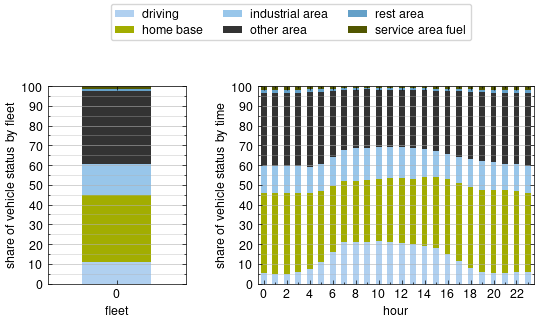

In [20]:
dv.plot_fleet_occupation(df_rt_joined_plot, truck_day_occ)

### Trucks residing at home base

C:\Users\ge56wuh\AppData\Local\Temp\ipykernel_31540\859019906.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=at_home_base.T, x='hour', y='home_base', palette="tab10", linewidth=2.5)


<Axes: xlabel='hour', ylabel='home_base'>

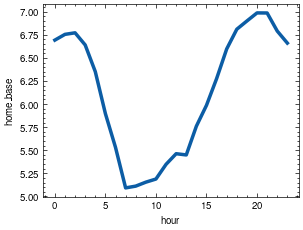

In [21]:
# TODO ?? num of trucks at depot > total num of trucks?? 
#  because I use truck_day_occ which shows time spent at depot not number of occurences at depot
#  use de_occupation instead

# TODO adjust to be similar to kde plot (but only one plot)
# TODO add legend (each color/line one freight forwarder)
# TODO later one line per freight forwarder

# try one: pretty sure this is wrong
num_days = (df_trips['start_time'].max() - df_trips['start_time'].min()).days + 1
at_home_base = truck_day_occ.loc[['home_base']] / (num_days * 60)

# try two:


sns.lineplot(data=at_home_base.T, x='hour', y='home_base', palette="tab10", linewidth=2.5)

## Energy Simulation: Loads at Depot

### Trip distances of trucks entering depot for each hour

h:\03 Code\sm-truck-fleet-electrification-paper\src\data_processing.py:463: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df_trips_copy.resample('1H').agg({
h:\03 Code\sm-truck-fleet-electrification-paper\src\data_processing.py:463: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df_trips_copy.resample('1H').agg({


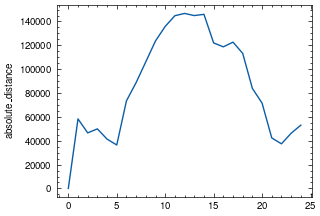

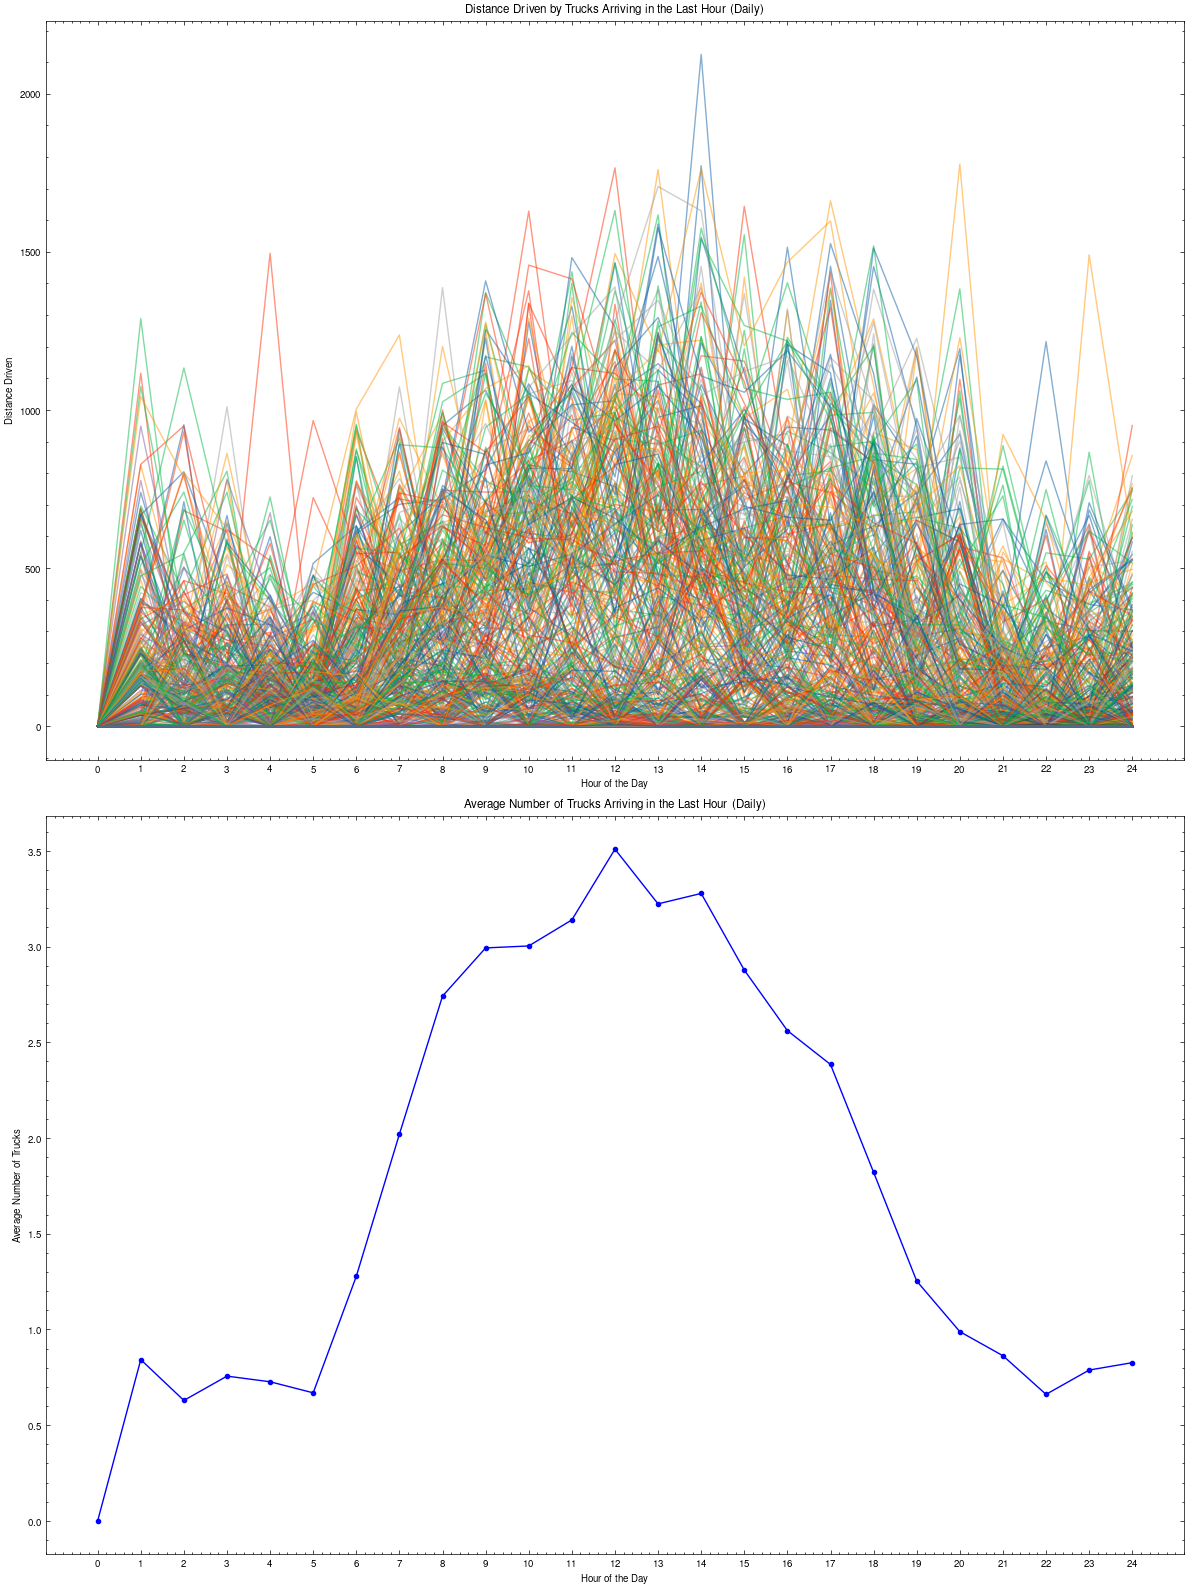

"\n        # Create a figure\n        plt.figure(figsize=(12, 8))\n\n        # Plot the absolute distance using seaborn\n        sns.lineplot(data=dist_arrival.loc['absolute_distance'])\n\n        # Set the x-axis to represent the 24 hours\n        plt.xticks(dist_arrival.columns)\n\n        # Add labels and title\n        plt.xlabel('Hour of the Day')\n        plt.ylabel('Distance Driven by Trucks arriving in the Last Hour') \n        plt.title('Absolute Distance Driven by Trucks Arriving in the Last Hour')\n\n        # Show the plot\n        plt.show()\n "

In [22]:
# TODO should I include the 0th column (all distance values = 0) or not?
dist_arrival = dp.aggregate_hourly_distance(df_trips)
dist_arrival_daily = dp.aggregate_hourly_distance(df_trips, per_day=True)

sns.lineplot(data=dist_arrival.loc['absolute_distance'].T)
dv.daily_arrival_pattern(dist_arrival_daily, dist_arrival)

# add column with 0s to the beginning of the df to represent the start of each day

# TODO create plot similar to the kde plot but not with density but with absolute numbers 
#       (one line per freight forwarder, different colors, legend on the right)

# Current plotting options:

    # 1: sns.lineplot(data=dist_arrival.loc['absolute_distance'].T)
    # 2: sns.barplot(data=dist_arrival.loc['absolute_distance'].T)

    # 3
"""
        # Create a figure
        plt.figure(figsize=(12, 8))

        # Plot the absolute distance using seaborn
        sns.lineplot(data=dist_arrival.loc['absolute_distance'])

        # Set the x-axis to represent the 24 hours
        plt.xticks(dist_arrival.columns)

        # Add labels and title
        plt.xlabel('Hour of the Day')
        plt.ylabel('Distance Driven by Trucks arriving in the Last Hour') 
        plt.title('Absolute Distance Driven by Trucks Arriving in the Last Hour')

        # Show the plot
        plt.show()
 """

    # 4: not in use (could potentially use if changed to look like plot_kde) 
    #    dv.daily_arrival_pattern(dist_arrival_daily, dist_arrival)